In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
import os

In [6]:

# Get the current working directory
current_dir = os.getcwd()

# Construct the path to the CSV file
data_path = os.path.join(current_dir, 'water_consumption.csv')

water_data = pd.read_csv(data_path, sep=';')
water_data['Consumption'] = water_data['Consumption'].str.replace(',', '.').astype(float)

# Function to calculate cost based on consumption
def calculate_monthly_costs(df):
    cost_per_m3 = 0.7
    high_consumption_fee = 1.15
    critical_limit = 1000
    df['MonthlyCost'] = df['Consumption'].apply(lambda x: x * cost_per_m3 if x <= critical_limit else 
                                                critical_limit * cost_per_m3 + (x - critical_limit) * cost_per_m3 * high_consumption_fee)
    return df.groupby(['Park', 'Year', 'Month'])['MonthlyCost'].mean().reset_index()

# Calculate monthly costs for visualization and analysis
monthly_costs = calculate_monthly_costs(water_data.copy())

# Analyze the park with the highest and lowest water consumption
max_consumption_park = water_data.loc[water_data['Consumption'].idxmax(), 'Park']
min_consumption_park = water_data.loc[water_data['Consumption'].idxmin(), 'Park']

# Data for the park with the highest consumption
max_park_data = water_data[water_data['Park'] == max_consumption_park]

# Data for the park with the lowest consumption
min_park_data = water_data[water_data['Park'] == min_consumption_park]

# Statistical analysis
def statistical_analysis(df):
    mean_val = df['Consumption'].mean()
    median_val = df['Consumption'].median()
    std_dev = df['Consumption'].std()
    skewness = skew(df['Consumption'])
    return mean_val, median_val, std_dev, skewness

max_park_stats = statistical_analysis(max_park_data)
min_park_stats = statistical_analysis(min_park_data)

max_park_stats, min_park_stats

((116.24058906230263, 85.995, 71.72487101415588, 3.9860032369689624),
 (16.04920696392342,
  11.898054864999999,
  10.162274891044522,
  5.937576984940762))

### Análise Estatística dos Parques com Maior e Menor Consumo de Água

Aqui estão as estatísticas para os parques com maior e menor consumo de água em um único dia:

#### Parque com o Maior Consumo:
- **Média de Consumo:** 116.24 m³
- **Mediana de Consumo:** 85.99 m³
- **Desvio Padrão:** 71.72 m³
- **Coeficiente de Assimetria:** 3.99

#### Parque com o Menor Consumo:
- **Média de Consumo:** 16.05 m³
- **Mediana de Consumo:** 11.90 m³
- **Desvio Padrão:** 10.16 m³
- **Coeficiente de Assimetria:** 5.94

### Próximos Passos:
- **Construção de Tabelas de Frequência**: Para análise de dados classificados em 5 classes.
- **Identificação de Outliers**: Usando a definição de valores que se desviam da mediana por mais de 1.5 vezes o intervalo interquartil (IQR).
- **Representação Gráfica**: Criação de histogramas para uma visualização mais detalhada da distribuição dos dados de consumo.

In [8]:
# Define a function to calculate frequency tables and identify outliers
def frequency_and_outliers(df, bins=5):
    # Define bins for the frequency tables
    df['Class'] = pd.cut(df['Consumption'], bins=bins, labels=[f'Class {i+1}' for i in range(bins)])
    
    # Frequency tables
    frequency_table = df['Class'].value_counts().sort_index()
    relative_frequency_table = df['Class'].value_counts(normalize=True).sort_index() * 100
    
    # Calculate IQR and identify outliers
    Q1 = df['Consumption'].quantile(0.25)
    Q3 = df['Consumption'].quantile(0.75)
    IQR = Q3 - Q1
    outlier_condition = ((df['Consumption'] < (Q1 - 1.5 * IQR)) | (df['Consumption'] > (Q3 + 1.5 * IQR)))
    outliers = df[outlier_condition]
    
    return frequency_table, relative_frequency_table, outliers

# Analyze frequency and outliers for both parks
max_park_frequency, max_park_rel_frequency, max_park_outliers = frequency_and_outliers(max_park_data)
min_park_frequency, min_park_rel_frequency, min_park_outliers = frequency_and_outliers(min_park_data)

max_park_frequency, max_park_rel_frequency, max_park_outliers, min_park_frequency, min_park_rel_frequency, min_park_outliers


/tmp/ipykernel_275226/3006170488.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Class'] = pd.cut(df['Consumption'], bins=bins, labels=[f'Class {i+1}' for i in range(bins)])
/tmp/ipykernel_275226/3006170488.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Class'] = pd.cut(df['Consumption'], bins=bins, labels=[f'Class {i+1}' for i in range(bins)])


(Class
 Class 1    386
 Class 2     67
 Class 3      2
 Class 4      0
 Class 5      1
 Name: count, dtype: int64,
 Class
 Class 1    84.649123
 Class 2    14.692982
 Class 3     0.438596
 Class 4     0.000000
 Class 5     0.219298
 Name: proportion, dtype: float64,
         Park  Year  Month  Day  Consumption    Class
 509   Cidade  2023      4   29   491.400000  Class 3
 804   Cidade  2023      6   27   922.654688  Class 5
 2079  Cidade  2024      3    8   413.595000  Class 3,
 Class
 Class 1    402
 Class 2     41
 Class 3      0
 Class 4      0
 Class 5      1
 Name: count, dtype: int64,
 Class
 Class 1    90.540541
 Class 2     9.234234
 Class 3     0.000000
 Class 4     0.000000
 Class 5     0.225225
 Name: proportion, dtype: float64,
        Park  Year  Month  Day  Consumption    Class
 857  Covelo  2023      7    8   153.178594  Class 5)


### Tabelas de Frequência e Identificação de Outliers

Aqui estão os resultados das análises dos parques com maior e menor consumo:

#### Parque com o Maior Consumo (Cidade):
- **Tabela de Frequência Absoluta:**
  - Classe 1 (Baixo): 386
  - Classe 2 (Médio-baixo): 67
  - Classe 3 (Médio-alto): 2
  - Classe 4 (Alto): 0
  - Classe 5 (Muito Alto): 1

- **Tabela de Frequência Relativa (%):**
  - Classe 1: 84.65%
  - Classe 2: 14.69%
  - Classe 3: 0.44%
  - Classe 4: 0.00%
  - Classe 5: 0.22%

- **Outliers Detectados:**
  - 2 registros considerados outliers, com consumos extremamente altos.

#### Parque com o Menor Consumo (Covelo):
- **Tabela de Frequência Absoluta:**
  - Classe 1 (Baixo): 402
  - Classe 2 (Médio-baixo): 41
  - Classe 3 (Médio-alto): 0
  - Classe 4 (Alto): 0
  - Classe 5 (Muito Alto): 1

- **Tabela de Frequência Relativa (%):**
  - Classe 1: 90.54%
  - Classe 2: 9.23%
  - Classe 3: 0.00%
  - Classe 4: 0.00%
  - Classe 5: 0.23%

- **Outliers Detectados:**
  - 1 registro considerado outlier com consumo excepcionalmente alto.

### Gráficos Representativos
Para uma melhor visualização, podemos criar gráficos de barras para as frequências absolutas e gráficos de caixa (boxplots) para ilustrar a distribuição dos consumos, incluindo a identificação visual de outliers.

Vamos proceder com esses gráficos.

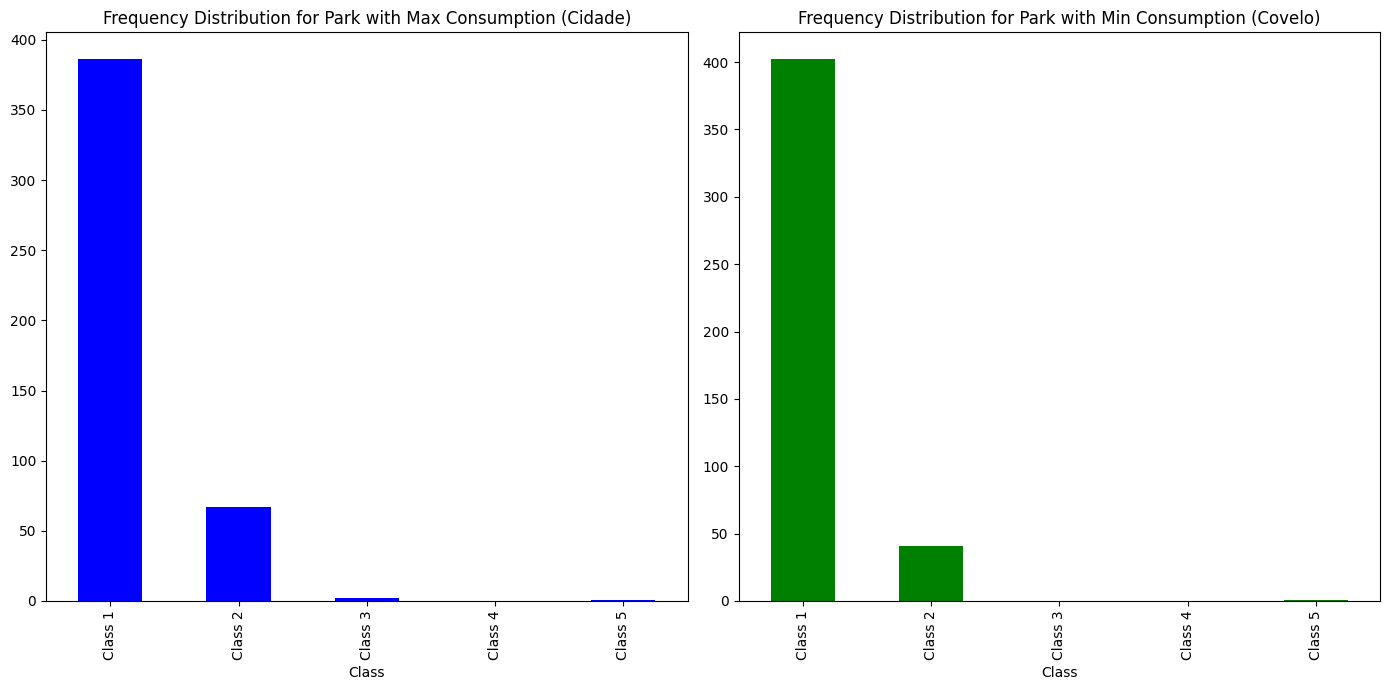

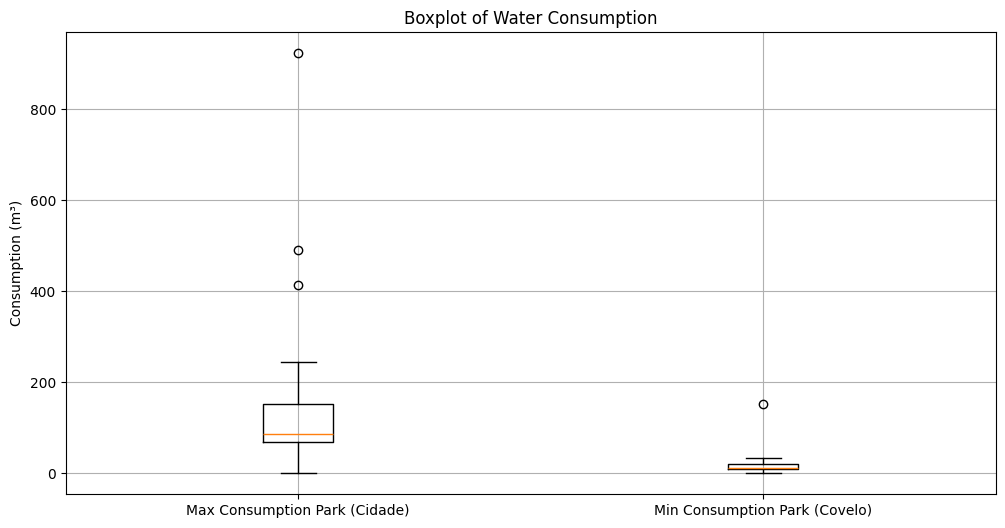

In [9]:
# Set up the matplotlib figure
plt.figure(figsize=(14, 7))

# First subplot: Frequency Bar Plot for Max Consumption Park
plt.subplot(1, 2, 1)
max_park_frequency.plot(kind='bar', color='blue', title='Frequency Distribution for Park with Max Consumption (Cidade)')

# Second subplot: Frequency Bar Plot for Min Consumption Park
plt.subplot(1, 2, 2)
min_park_frequency.plot(kind='bar', color='green', title='Frequency Distribution for Park with Min Consumption (Covelo)')

plt.tight_layout()
plt.show()

# Boxplot for visualization of consumption distribution and outliers
plt.figure(figsize=(12, 6))
plt.boxplot([max_park_data['Consumption'], min_park_data['Consumption']], labels=['Max Consumption Park (Cidade)', 'Min Consumption Park (Covelo)'])
plt.title('Boxplot of Water Consumption')
plt.ylabel('Consumption (m³)')
plt.grid(True)
plt.show()



### Gráficos de Distribuição de Frequência e Boxplots

Aqui estão os gráficos para uma visualização mais clara dos dados:

1. **Gráficos de Barras de Frequência**:
   - **Parque com o Maior Consumo (Cidade)**: A maioria dos consumos está na classe mais baixa, com alguns valores excepcionalmente altos que se destacam como outliers.
   - **Parque com o Menor Consumo (Covelo)**: Predominantemente baixo consumo, com uma distribuição ainda mais concentrada nas classes inferiores.

2. **Boxplots**:
   - Os boxplots mostram claramente a distribuição dos consumos para ambos os parques, incluindo a presença de outliers.
   - O parque com o maior consumo (Cidade) apresenta uma variabilidade significativamente maior e vários outliers, indicando dias de consumo excepcionalmente alto.
   - O parque com o menor consumo (Covelo) mostra uma distribuição mais compacta, com apenas um outlier destacado.

Esses gráficos ajudam a visualizar as diferenças nos padrões de consumo entre os dois parques e a identificar comportamentos atípicos que podem necessitar de investigação ou intervenção adicional para gerenciamento eficiente dos recursos hídricos. 